In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import RobustScaler
import shap

In [39]:
df = pd.read_csv("kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [41]:
df = df.drop(['id', 'date'], axis=1)

#### Distribution of Price

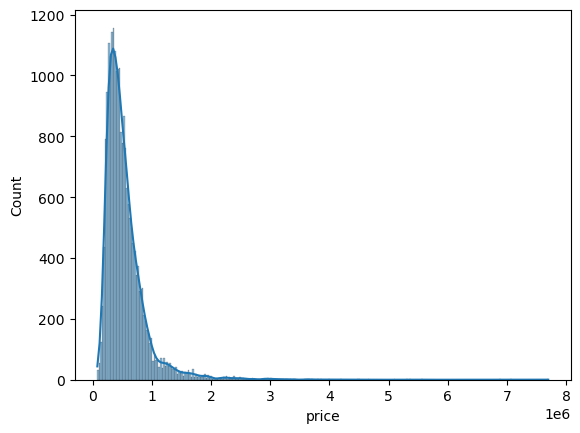

In [42]:
sns.histplot(df['price'], kde=True)
plt.show()

#### Square Footage of Living Area vs Price

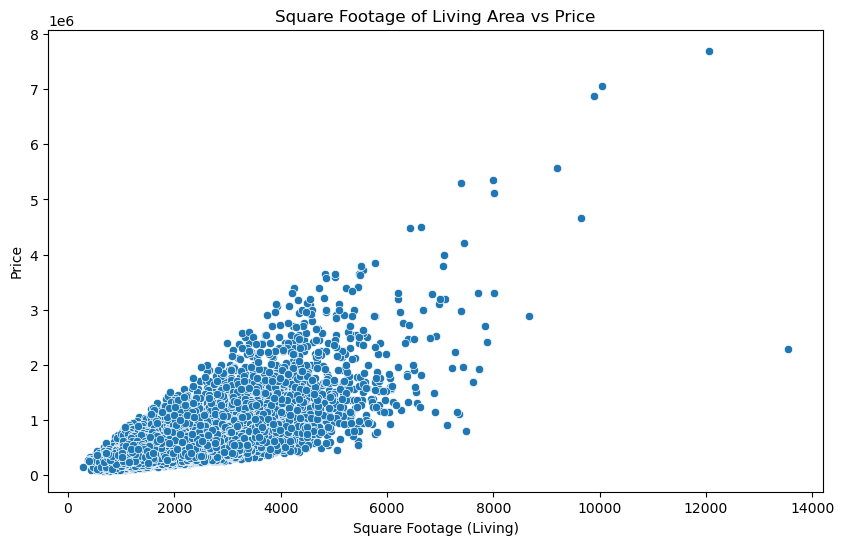

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sqft_living', y='price', data=df)
plt.title('Square Footage of Living Area vs Price')
plt.xlabel('Square Footage (Living)')
plt.ylabel('Price')
plt.show()

#### Impact Bedrooms on Price

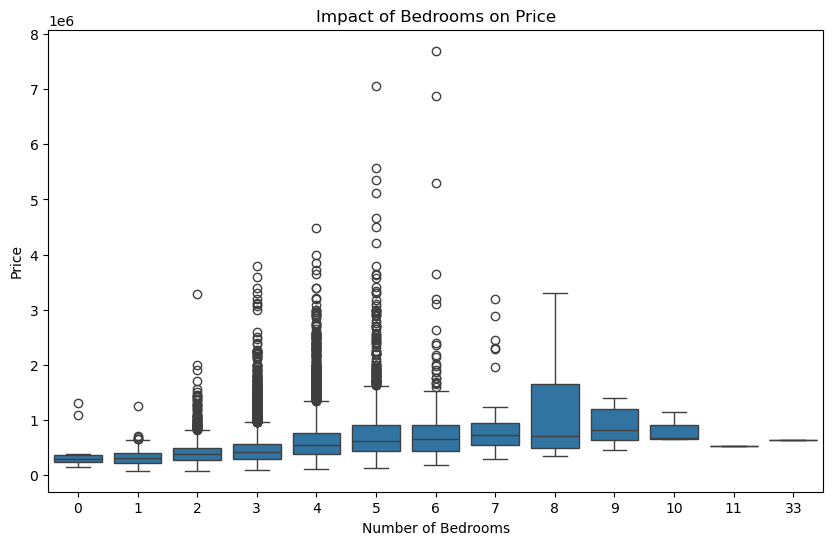

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title('Impact of Bedrooms on Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.show()

### Feature Engineering

In [45]:
df['house_age'] = 2015 - df['yr_built']
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
df['effective_age'] = 2015 - df[['yr_built', 'yr_renovated']].max(axis=1)
df['has_basement'] = df['sqft_basement'].apply(lambda x: 1 if x > 0 else 0)
df['living_lot_ratio'] = df['sqft_living'] / df['sqft_lot']
df['sqft_per_floor'] = df['sqft_living'] / df['floors']
df['bath_bed_ratio'] = df['bathrooms'] / (df['bedrooms'] + 1)

center_lat = df['lat'].median()
center_long = df['long'].median()
df['dist_to_center'] = np.sqrt((df['lat'] - center_lat)**2 + (df['long'] - center_long)**2)

df = df.drop(['yr_built', 'yr_renovated'], axis=1)

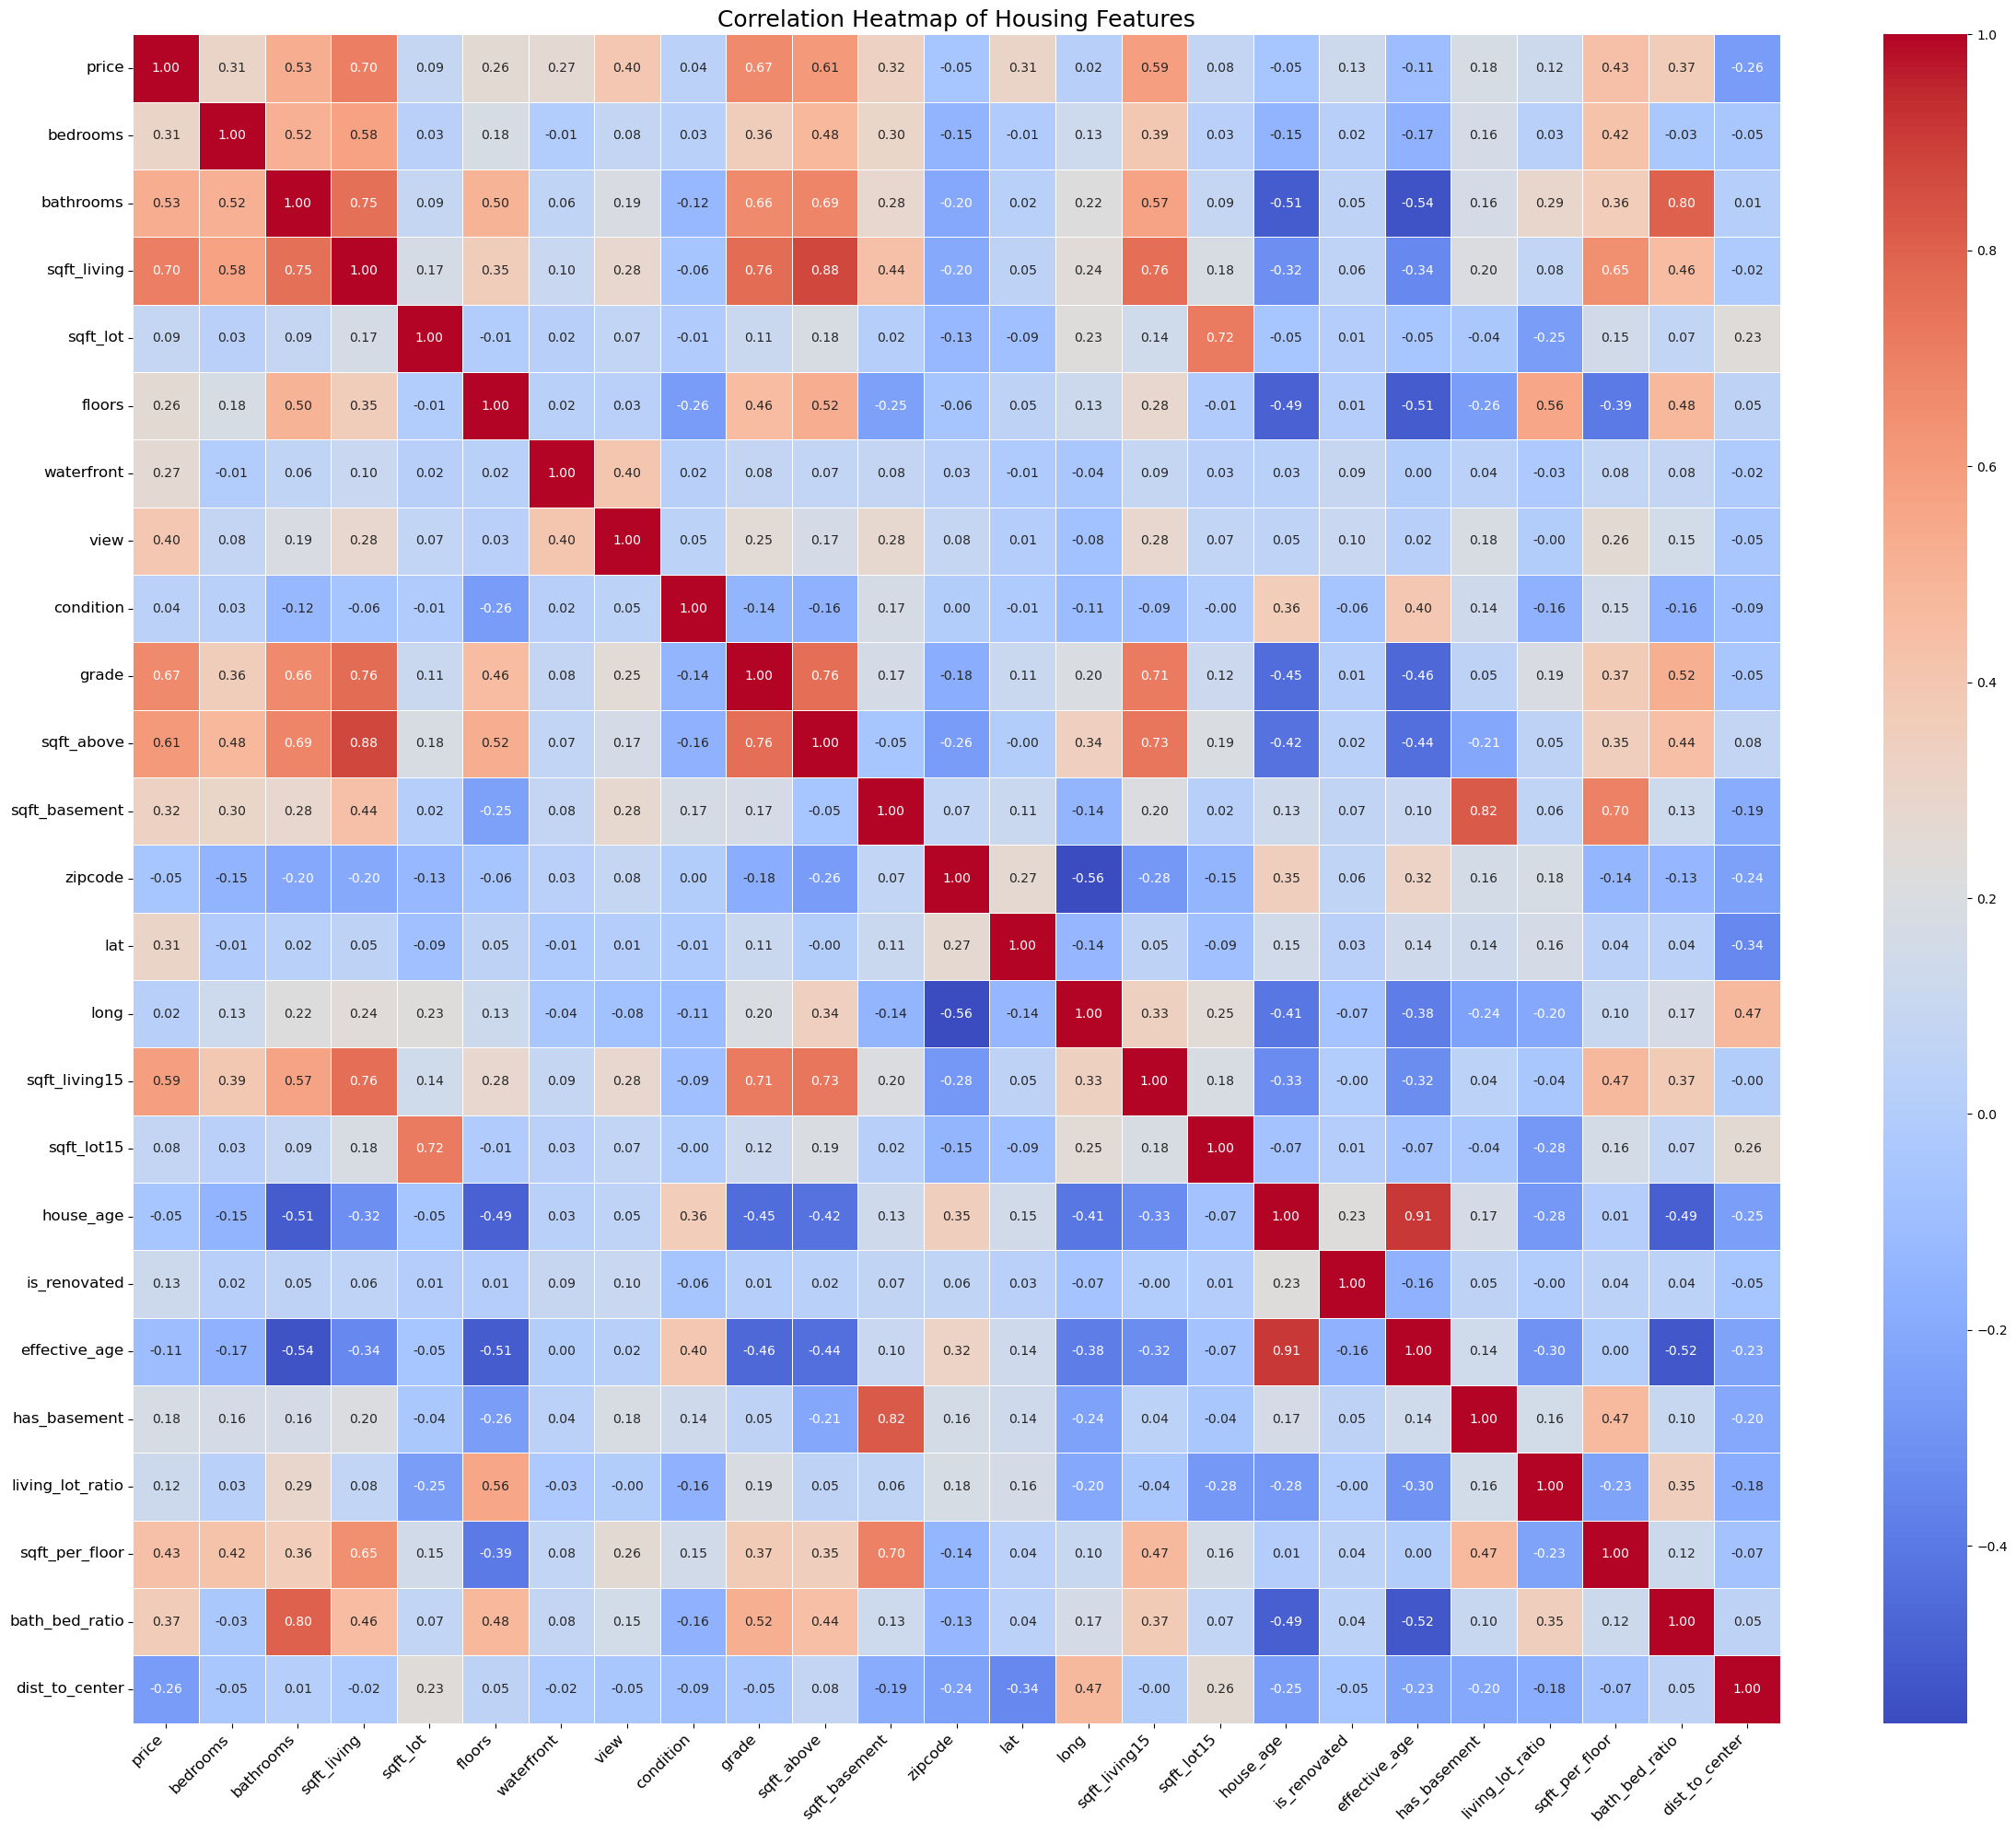

In [46]:
plt.figure(figsize=(24, 20))
sns.heatmap(
    df.corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    annot_kws={"size": 10}, 
    linewidths=0.5
)
plt.title('Correlation Heatmap of Housing Features', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

#### Split

In [47]:
x = df.drop(['price'], axis=1)
y = df['price']

x_train, x_test, y_train, y_test, = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [48]:
print("x_train size", x_train.shape[0])
print("x_test size", x_test.shape[0])
print("y_train size", y_train.shape[0])
print("y_test size", y_test.shape[0])

x_train size 17290
x_test size 4323
y_train size 17290
y_test size 4323


In [49]:
def evaluasi_model(model, nama_model):
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    
    mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
    mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
    
    gap_r2 = (r2_train - r2_test) * 100
    
    print(f"Model: {nama_model} :")
    print(f"R2 : {r2_train:.4f} / {r2_test:.4f}")
    print(f"MAE : {mae_train:.2f} / {mae_test:.2f}")
    print(f"MAPE : {mape_train:.4f} / {mape_test:.4f}")
    print(f"Gap R2 : {gap_r2:.2f}%")
    
    if r2_train < 0.60:
        print("UNDERFITTING")
    elif gap_r2 > 5.0:
        print("OVERFITTING")
    else:
        print("GOOD FIT")
    print()
    
    return r2_test, mae_test, mape_test

### Decision Tree (BASELINE & TUNED)

In [50]:
def DT_model():
    pipeline_base = Pipeline(steps=[
        ("preprocessor", ColumnTransformer(transformers=[("num", RobustScaler(), x.columns)])),
        ("model", DecisionTreeRegressor(random_state=42))
    ])
    pipeline_base.fit(x_train, y_train)
    r2_base, mae_base, mape_base = evaluasi_model(pipeline_base, "DT Baseline")
    
    param_grid_dt = {
        'model__max_depth': [5, 8],
        'model__min_samples_split': [100, 200],
        'model__min_samples_leaf': [50, 100],
        'model__max_features': ['sqrt', 'log2']
    }
    grid = GridSearchCV(pipeline_base, param_grid=param_grid_dt, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(x_train, y_train)
    r2_tuned, mae_tuned, mape_tuned = evaluasi_model(grid.best_estimator_, "DT Tuned")
    
    return {
        'baseline': pipeline_base, 
        'tuned': grid.best_estimator_, 
        'r2_base': r2_base, 'mae_base': mae_base, 'mape_base': mape_base,
        'r2_tuned': r2_tuned, 'mae_tuned': mae_tuned, 'mape_tuned': mape_tuned
    }

In [51]:
dt_evaluation = DT_model()

Model: DT Baseline :
R2 : 0.9992 / 0.6902
MAE : 941.90 / 106527.09
MAPE : 0.0030 / 0.1872
Gap R2 : 30.91%
OVERFITTING

Model: DT Tuned :
R2 : 0.6778 / 0.6381
MAE : 112612.33 / 124010.98
MAPE : 0.2107 / 0.2213
Gap R2 : 3.96%
GOOD FIT



### Random Forest (BASELINE & TUNED)

In [52]:
def RF_model():
    pipeline_base = Pipeline(steps=[
        ("preprocessor", ColumnTransformer(transformers=[("num", RobustScaler(), x.columns)])),
        ("model", RandomForestRegressor(random_state=42))
    ])
    pipeline_base.fit(x_train, y_train)
    r2_base, mae_base, mape_base = evaluasi_model(pipeline_base, "RF Baseline")
    
    param_grid_rf = {
        'model__n_estimators': [100],
        'model__max_depth': [8, 10],
        'model__min_samples_split': [100, 150],
        'model__min_samples_leaf': [50, 80],
        'model__max_samples': [0.6, 0.7]
    }
    grid = GridSearchCV(pipeline_base, param_grid=param_grid_rf, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(x_train, y_train)
    r2_tuned, mae_tuned, mape_tuned = evaluasi_model(grid.best_estimator_, "RF Tuned")
    
    return {
        'baseline': pipeline_base, 
        'tuned': grid.best_estimator_, 
        'r2_base': r2_base, 'mae_base': mae_base, 'mape_base': mape_base,
        'r2_tuned': r2_tuned, 'mae_tuned': mae_tuned, 'mape_tuned': mape_tuned
    }

In [53]:
rf_evaluation = RF_model()

Model: RF Baseline :
R2 : 0.9835 / 0.8614
MAE : 25625.35 / 72596.50
MAPE : 0.0493 / 0.1310
Gap R2 : 12.21%
OVERFITTING

Model: RF Tuned :
R2 : 0.7979 / 0.7845
MAE : 80680.58 / 90655.90
MAPE : 0.1479 / 0.1602
Gap R2 : 1.34%
GOOD FIT



### GBM (BASELINE & TUNED)

In [54]:
def GBM_model():
    pipeline_base = Pipeline(steps=[
        ("preprocessor", ColumnTransformer(transformers=[("num", RobustScaler(), x.columns)])),
        ("model", GradientBoostingRegressor(random_state=42))
    ])
    pipeline_base.fit(x_train, y_train)
    r2_base, mae_base, mape_base = evaluasi_model(pipeline_base, "GBM Baseline")
    
    param_grid_gbm = {
        'model__n_estimators': [100, 150],
        'model__learning_rate': [0.03, 0.05],
        'model__max_depth': [3, 5],
        'model__subsample': [0.6, 0.7],
        'model__min_samples_leaf': [50, 80]
    }
    grid = GridSearchCV(pipeline_base, param_grid=param_grid_gbm, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(x_train, y_train)
    r2_tuned, mae_tuned, mape_tuned = evaluasi_model(grid.best_estimator_, "GBM Tuned")
    
    return {
        'baseline': pipeline_base, 
        'tuned': grid.best_estimator_, 
        'r2_base': r2_base, 'mae_base': mae_base, 'mape_base': mape_base,
        'r2_tuned': r2_tuned, 'mae_tuned': mae_tuned, 'mape_tuned': mape_tuned
    }

In [55]:
gbm_evaluation = GBM_model()

Model: GBM Baseline :
R2 : 0.9076 / 0.8638
MAE : 70860.43 / 80341.79
MAPE : 0.1416 / 0.1501
Gap R2 : 4.38%
GOOD FIT

Model: GBM Tuned :
R2 : 0.8923 / 0.8786
MAE : 67384.25 / 75477.97
MAPE : 0.1318 / 0.1397
Gap R2 : 1.37%
GOOD FIT



### XGB (BASELINE & TUNED)

In [56]:
def XGB_model():
    pipeline_base = Pipeline(steps=[
        ("preprocessor", ColumnTransformer(transformers=[("num", RobustScaler(), x.columns)])),
        ("model", XGBRegressor(random_state=42))
    ])
    pipeline_base.fit(x_train, y_train)
    r2_base, mae_base, mape_base = evaluasi_model(pipeline_base, "XGB Baseline")
    
    param_grid_xgb = {
        'model__n_estimators': [100, 150],
        'model__learning_rate': [0.03, 0.05],
        'model__max_depth': [3, 5],
        'model__subsample': [0.6, 0.7],
        'model__colsample_bytree': [0.6, 0.7],
        'model__min_child_weight': [15, 30],
        'model__reg_alpha': [10, 50],
        'model__reg_lambda': [10, 50]
    }
    grid = GridSearchCV(pipeline_base, param_grid=param_grid_xgb, cv=3, scoring='r2', n_jobs=-1)
    grid.fit(x_train, y_train)
    r2_tuned, mae_tuned, mape_tuned = evaluasi_model(grid.best_estimator_, "XGB Tuned")
    
    return {
        'baseline': pipeline_base, 
        'tuned': grid.best_estimator_, 
        'r2_base': r2_base, 'mae_base': mae_base, 'mape_base': mape_base,
        'r2_tuned': r2_tuned, 'mae_tuned': mae_tuned, 'mape_tuned': mape_tuned
    }

In [57]:
xgb_evaluation = XGB_model()

Model: XGB Baseline :
R2 : 0.9780 / 0.8766
MAE : 38580.26 / 71258.55
MAPE : 0.0872 / 0.1304
Gap R2 : 10.14%
OVERFITTING

Model: XGB Tuned :
R2 : 0.9122 / 0.8885
MAE : 64518.34 / 73428.44
MAPE : 0.1294 / 0.1374
Gap R2 : 2.37%
GOOD FIT



#### Evaluation

In [58]:
Eval = {
    "Decision Tree": dt_evaluation,
    "Random Forest": rf_evaluation,
    "Gradient Boosting": gbm_evaluation,
    "XGBoost": xgb_evaluation
}

for model, result in Eval.items():
    print(f"Model: {model}")
    print(f"  [Baseline] R2: {result['r2_base']:.4f} | MAE: {result['mae_base']:,.2f} | MAPE: {result['mape_base']:.4f}")
    print(f"  [Tuned]    R2: {result['r2_tuned']:.4f} | MAE: {result['mae_tuned']:,.2f} | MAPE: {result['mape_tuned']:.4f}")
    print("-" * 70)

Model: Decision Tree
  [Baseline] R2: 0.6902 | MAE: 106,527.09 | MAPE: 0.1872
  [Tuned]    R2: 0.6381 | MAE: 124,010.98 | MAPE: 0.2213
----------------------------------------------------------------------
Model: Random Forest
  [Baseline] R2: 0.8614 | MAE: 72,596.50 | MAPE: 0.1310
  [Tuned]    R2: 0.7845 | MAE: 90,655.90 | MAPE: 0.1602
----------------------------------------------------------------------
Model: Gradient Boosting
  [Baseline] R2: 0.8638 | MAE: 80,341.79 | MAPE: 0.1501
  [Tuned]    R2: 0.8786 | MAE: 75,477.97 | MAPE: 0.1397
----------------------------------------------------------------------
Model: XGBoost
  [Baseline] R2: 0.8766 | MAE: 71,258.55 | MAPE: 0.1304
  [Tuned]    R2: 0.8885 | MAE: 73,428.44 | MAPE: 0.1374
----------------------------------------------------------------------


#### Learning Curve

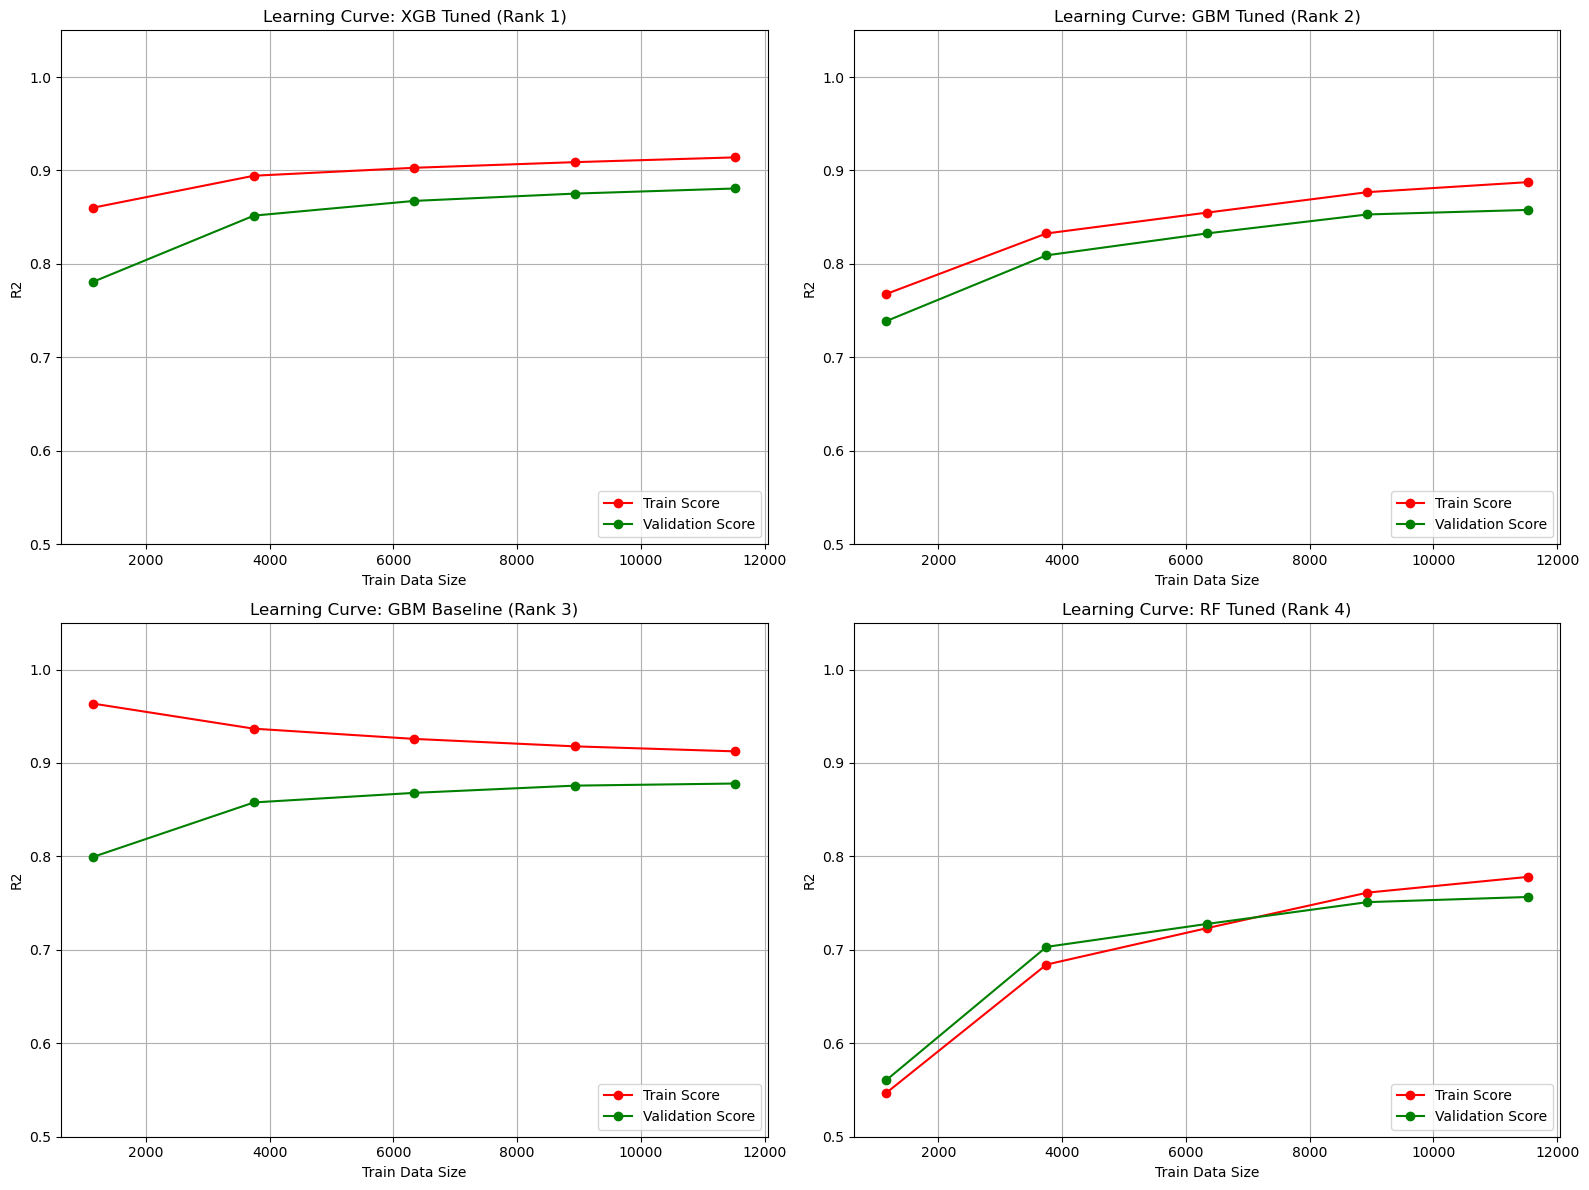

In [59]:
top_models = [
    (xgb_evaluation['tuned'], "Learning Curve: XGB Tuned (Rank 1)"),
    (gbm_evaluation['tuned'], "Learning Curve: GBM Tuned (Rank 2)"),
    (gbm_evaluation['baseline'], "Learning Curve: GBM Baseline (Rank 3)"),
    (rf_evaluation['tuned'], "Learning Curve: RF Tuned (Rank 4)")
]

def plot_lr(model, x, y, ax, judul):
    train_sizes, train_scores, val_scores = learning_curve(
        model, x, y, train_sizes=np.linspace(0.1, 1.0, 5),
        cv=3, scoring="r2", n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color="r", label="Train Score")
    ax.plot(train_sizes, val_mean, 'o-', color="g", label="Validation Score")
    ax.set_title(judul)
    ax.set_xlabel("Train Data Size")
    ax.set_ylabel("R2")
    ax.set_ylim(0.5, 1.05)
    ax.legend(loc="lower right")
    ax.grid(True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax = axes.ravel()

for i, (model, judul) in enumerate(top_models):
    plot_lr(model, x_train, y_train, ax[i], judul)

plt.tight_layout()
plt.show()

#### Feature Importance XGB Tuned (Rank 1)

C:\Users\Hylmi Razzan\AppData\Local\Temp\ipykernel_22056\3797984432.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=tabel_feature, palette='viridis')


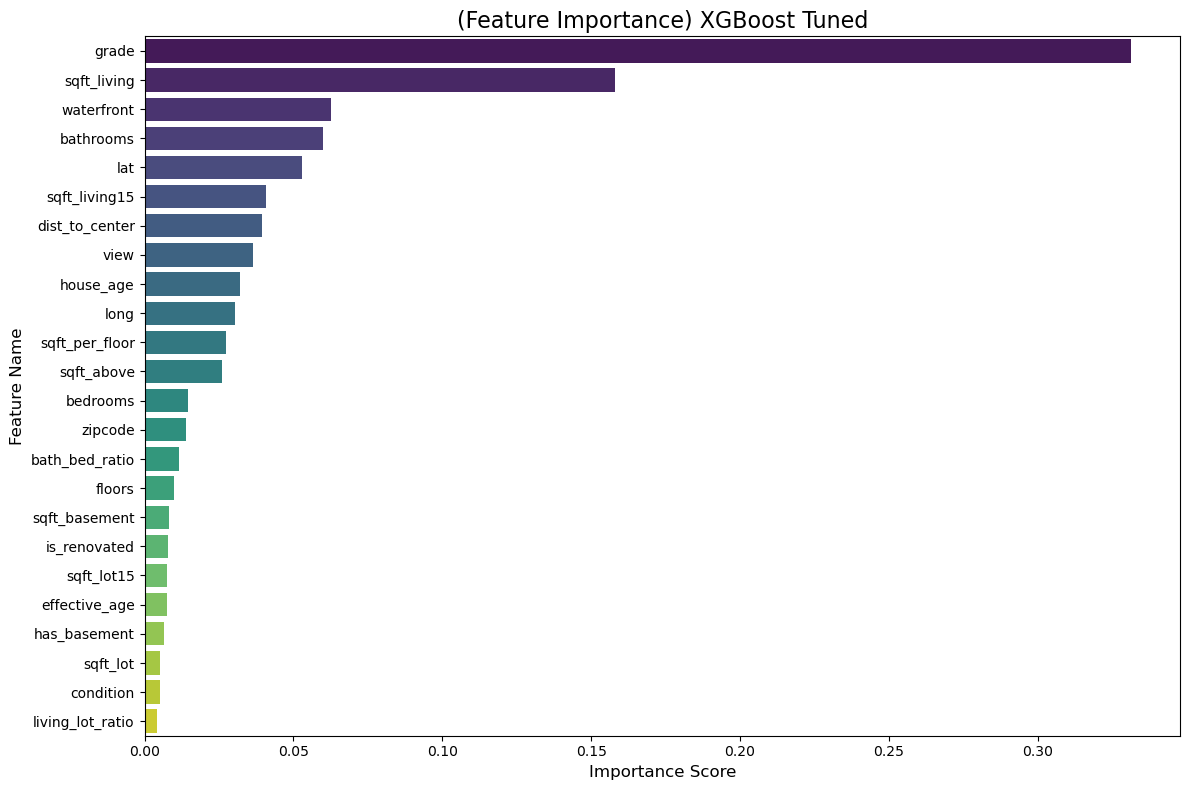

In [60]:
best_model = xgb_evaluation['tuned'].named_steps['model']
importance_score = best_model.feature_importances_
col_name = x.columns

tabel_feature = pd.DataFrame({
    'Feature': col_name,
    'Importance': importance_score
})

tabel_feature = tabel_feature.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=tabel_feature, palette='viridis')

plt.title('(Feature Importance) XGBoost Tuned', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

plt.tight_layout()
plt.show()

#### SHAP XGB Tuned (Rank 1)

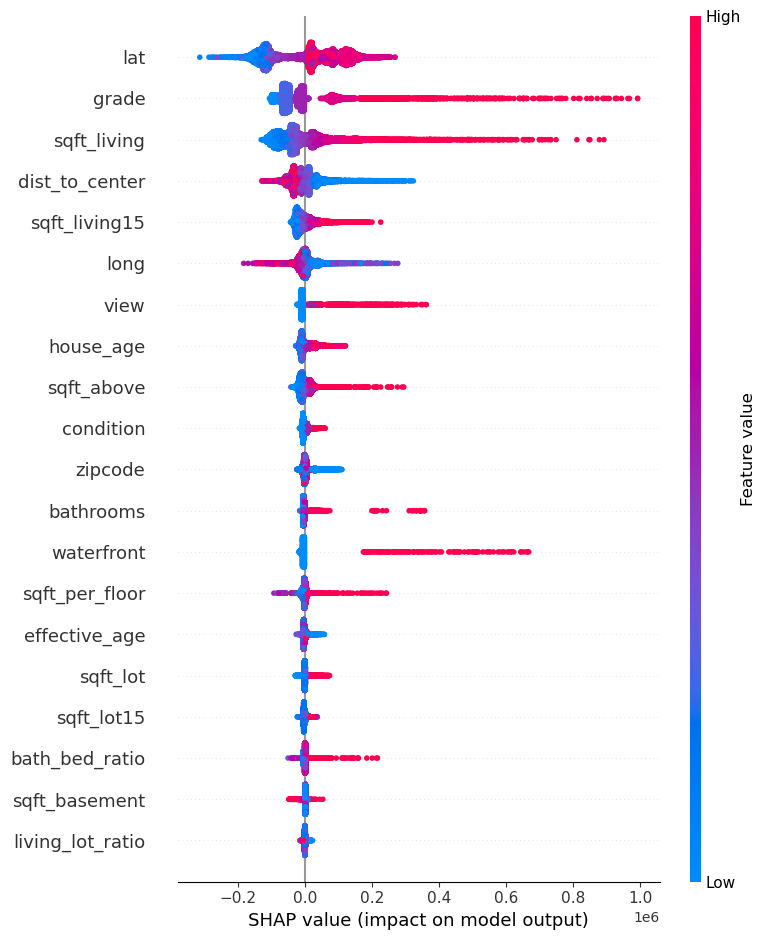

In [64]:
best_model = xgb_evaluation['tuned'].named_steps['model']
preprocessor = xgb_evaluation['tuned'].named_steps['preprocessor']

x_train_scaled = preprocessor.transform(x_train)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(x_train_scaled)

shap.summary_plot(shap_values, features=x_train_scaled, feature_names=x.columns)

#### Conclusions

#### Price Factor Conclusions:
* Main Rule: The model relies mostly on grade (quality) and sqft_living (size) to make its decisions.
* Biggest Impact: However, location (lat) has the strongest real impact on changing the final price tag.
* Realistic Logic: The model correctly predicts higher prices for homes that are high quality, large, close to the city center, or have waterfront access

#### Deployment Readiness Conclusion:
* No Overfitting: The R2 gap between train and test is only 2.37% (very safe, well below 5% limit).
* High Accuracy: A Test R2 of 88.85% means the model is highly accurate at guessing the price patterns.
* Acceptable Error: The MAPE (error rate) of 13.74% is completely normal and acceptable for real estate predictions (usually 10-15% is good).

#### Save Model

In [68]:
import joblib

joblib.dump(best_model, 'housing_price(XGB_tuned).pkl')

print("The model has been successfully saved as: housing_price(GBM_tuned).pkl")

The model has been successfully saved as: housing_price(GBM_tuned).pkl
